In [1]:
!py --version

Python 3.13.8


In [2]:
import joblib
import numpy as np
import pandas as pd
import sklearn as skl
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [3]:
print(f"numpy=={np.__version__}")
print(f"pandas=={pd.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"matplotlib=={mpl.__version__}")
print(f"scikitlearn=={skl.__version__}")
print(f"joblib=={joblib.__version__}")

numpy==2.3.3
pandas==2.3.3
seaborn==0.13.2
matplotlib==3.10.7
scikitlearn==1.7.2
joblib==1.5.2


In [4]:
RANDOM_STATE = 42

In [5]:
X_train = pd.read_csv(r'X_train_post.csv')
X_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
0,6.175,9.25992,29761.608,241.572139,8790.141,246.015,246.015,772.240,2.515,13.347,34.254,0.678,0.991,2
1,2.088,3.08664,3152.420,141.591057,6838.435,23.699,23.699,517.051,1.206,6.466,16.754,0.156,0.959,0
2,5.140,7.71660,21625.519,201.516623,8471.841,175.228,175.228,682.640,2.087,10.987,23.849,0.472,0.998,2
3,8.206,12.34656,50993.086,323.317950,9305.741,437.978,437.978,901.076,3.586,18.272,58.585,1.160,0.989,3
4,1.138,12.34656,748.284,141.564982,6642.099,7.624,7.624,468.577,1.115,6.029,8.163,0.093,0.973,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8348,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.018,3.607,18.693,60.083,1.189,0.998,3
8349,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.160,3.589,18.621,61.190,1.211,0.972,3
8350,9.300,12.34656,72759.686,372.841179,9751.200,644.872,644.872,1089.292,4.526,22.961,90.760,1.797,0.973,3
8351,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.989,2.497,13.129,34.453,0.682,0.953,2


In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8353 entries, 0 to 8352
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     8353 non-null   float64
 1   Скорость перехода через портал  8353 non-null   float64
 2   Приток Силы Потока              8353 non-null   float64
 3   Ритм магического ядра           8353 non-null   float64
 4   Поток Энергий                   8353 non-null   float64
 5   Сила Левого Потока              8353 non-null   float64
 6   Сила Правого Потока             8353 non-null   float64
 7   Пламя Стихий                    8353 non-null   float64
 8   Приток давления Выдоха Истока   8353 non-null   float64
 9   Давление выдоха Истока          8353 non-null   float64
 10  Печать Чародея                  8353 non-null   float64
 11  Эмульсия Истока                 8353 non-null   float64
 12  Дыхание Истока                  83

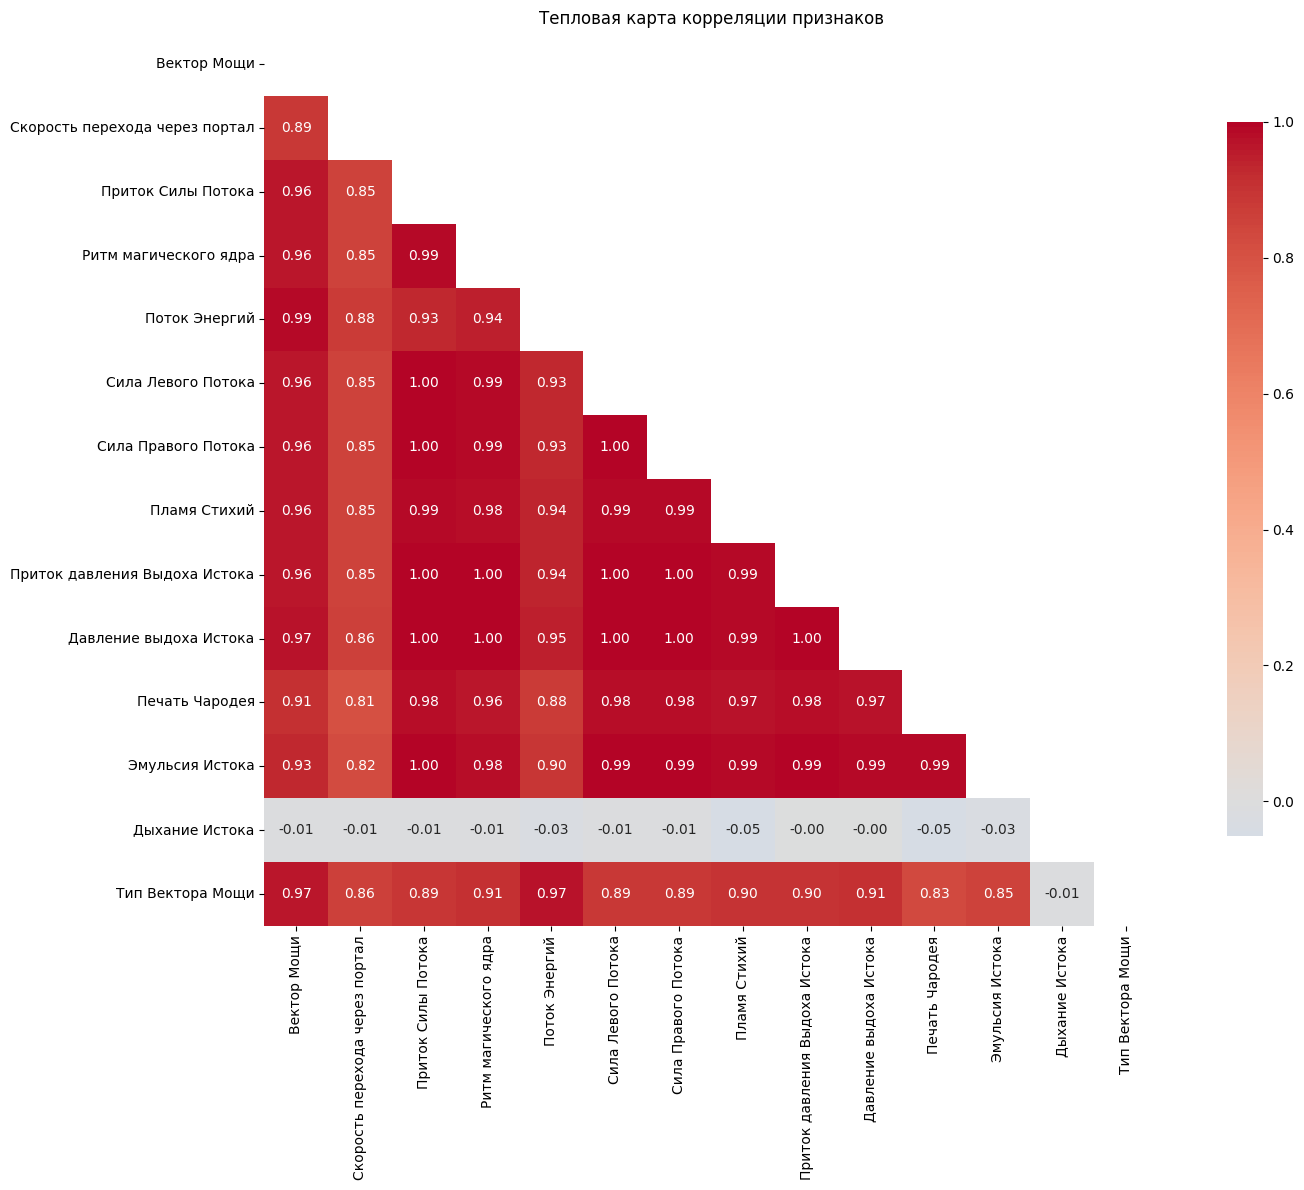

Вектор Мощи - Скорость перехода через портал: 0.888
Вектор Мощи - Приток Силы Потока: 0.961
Вектор Мощи - Ритм магического ядра: 0.962
Вектор Мощи - Поток Энергий: 0.986
Вектор Мощи - Сила Левого Потока: 0.959
Вектор Мощи - Сила Правого Потока: 0.959
Вектор Мощи - Пламя Стихий: 0.961
Вектор Мощи - Приток давления Выдоха Истока: 0.963
Вектор Мощи - Давление выдоха Истока: 0.969
Вектор Мощи - Печать Чародея: 0.913
Вектор Мощи - Эмульсия Истока: 0.931
Вектор Мощи - Тип Вектора Мощи: 0.967
Скорость перехода через портал - Приток Силы Потока: 0.851
Скорость перехода через портал - Ритм магического ядра: 0.852
Скорость перехода через портал - Поток Энергий: 0.876
Скорость перехода через портал - Сила Левого Потока: 0.849
Скорость перехода через портал - Сила Правого Потока: 0.849
Скорость перехода через портал - Пламя Стихий: 0.851
Скорость перехода через портал - Приток давления Выдоха Истока: 0.852
Скорость перехода через портал - Давление выдоха Истока: 0.858
Скорость перехода через порта

In [7]:
plt.figure(figsize=(16, 12))

correlation_matrix = X_train.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

strong_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            strong_corr_pairs.append((col1, col2, corr_value))
            print(f"{col1} - {col2}: {corr_value:.3f}")

In [8]:
def create_magic_features(df):
    df_transformed = df.copy()
    df_transformed['Сумма потоков'] = df_transformed['Сила Левого Потока'] + df_transformed['Сила Правого Потока']
    df_transformed['Общая сила потоков'] = df_transformed['Сумма потоков'] + df_transformed['Приток Силы Потока']
    df_transformed['Общая сила ядра'] = df_transformed['Ритм магического ядра'] * df_transformed['Приток Силы Потока']
    df_transformed['Общее давление'] = df_transformed['Приток давления Выдоха Истока'] + df_transformed['Давление выдоха Истока']
    df_transformed['Магическая производительность'] = (df_transformed['Скорость перехода через портал'] / 
                                                     (df_transformed['Эмульсия Истока'] + 1e-8))
    df_transformed['Эффективность ядра'] = (df_transformed['Общая сила ядра'] / 
                                          (df_transformed['Эмульсия Истока'] + 1e-8))
    
    return df_transformed.drop(['Сила Левого Потока', 'Сила Правого Потока', 'Сумма потоков', 'Приток Силы Потока', 'Приток давления Выдоха Истока', 'Давление выдоха Истока'], axis=1)

In [9]:
X_train_transformed = create_magic_features(X_train)
X_train_transformed

,Вектор Мощи,Скорость перехода через портал,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра
0,6.175,9.25992,241.572139,8790.141,772.240,34.254,0.678,0.991,2,30253.638,7.189575e+06,15.862,13.657699,1.060409e+07
1,2.088,3.08664,141.591057,6838.435,517.051,16.754,0.156,0.959,0,3199.818,4.463545e+05,7.672,19.786153,2.861246e+06
2,5.140,7.71660,201.516623,8471.841,682.640,23.849,0.472,0.998,2,21975.975,4.357902e+06,13.074,16.348728,9.232842e+06
3,8.206,12.34656,323.317950,9305.741,901.076,58.585,1.160,0.989,3,51869.042,1.648698e+07,21.858,10.643586,1.421291e+07
4,1.138,12.34656,141.564982,6642.099,468.577,8.163,0.093,0.973,0,763.532,1.059308e+05,7.144,132.758695,1.139041e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8348,8.206,12.34656,323.300567,9292.800,915.018,60.083,1.189,0.998,3,51865.526,1.648499e+07,22.300,10.383986,1.386458e+07
8349,8.206,12.34656,323.319312,9306.729,933.160,61.190,1.211,0.972,3,51869.728,1.648724e+07,22.210,10.195343,1.361457e+07
8350,9.300,12.34656,372.841179,9751.200,1089.292,90.760,1.797,0.973,3,74049.430,2.712781e+07,27.487,6.870651,1.509616e+07
8351,6.175,9.25992,241.615179,8842.649,779.989,34.453,0.682,0.953,2,30289.777,7.199420e+06,15.626,13.577595,1.055633e+07


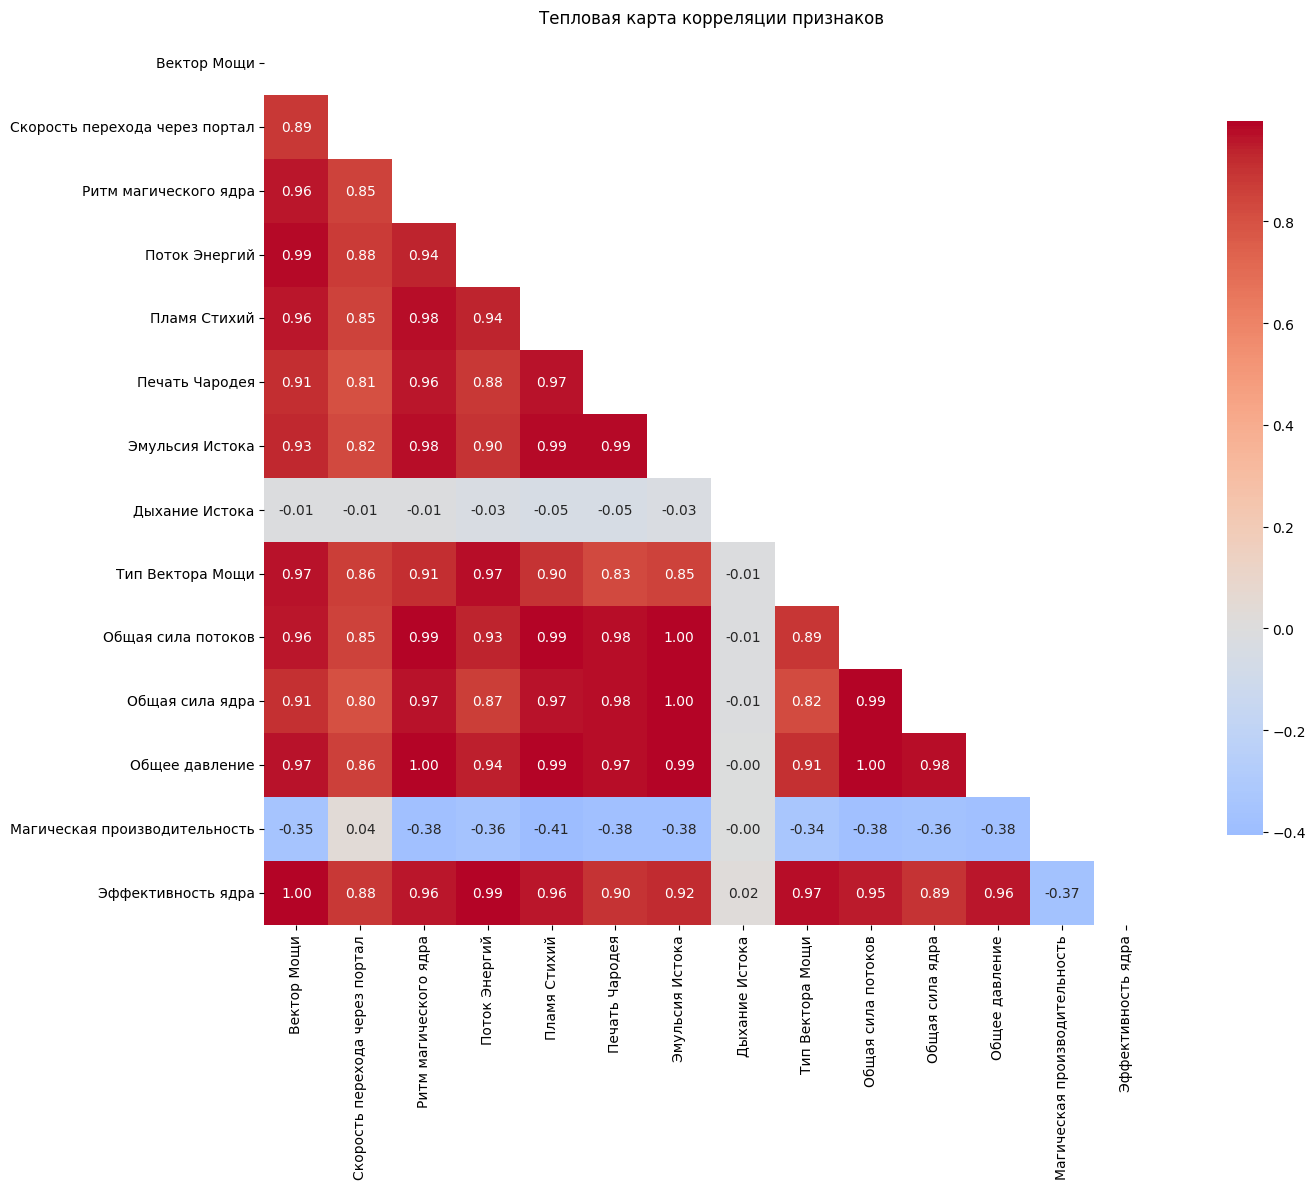

Вектор Мощи - Скорость перехода через портал: 0.888
Вектор Мощи - Ритм магического ядра: 0.962
Вектор Мощи - Поток Энергий: 0.986
Вектор Мощи - Пламя Стихий: 0.961
Вектор Мощи - Печать Чародея: 0.913
Вектор Мощи - Эмульсия Истока: 0.931
Вектор Мощи - Тип Вектора Мощи: 0.967
Вектор Мощи - Общая сила потоков: 0.961
Вектор Мощи - Общая сила ядра: 0.908
Вектор Мощи - Общее давление: 0.968
Вектор Мощи - Эффективность ядра: 0.995
Скорость перехода через портал - Ритм магического ядра: 0.852
Скорость перехода через портал - Поток Энергий: 0.876
Скорость перехода через портал - Пламя Стихий: 0.851
Скорость перехода через портал - Печать Чародея: 0.806
Скорость перехода через портал - Эмульсия Истока: 0.823
Скорость перехода через портал - Тип Вектора Мощи: 0.861
Скорость перехода через портал - Общая сила потоков: 0.850
Скорость перехода через портал - Общая сила ядра: 0.802
Скорость перехода через портал - Общее давление: 0.857
Скорость перехода через портал - Эффективность ядра: 0.883
Ритм м

In [10]:
plt.figure(figsize=(16, 12))

correlation_matrix = X_train_transformed.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

strong_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            strong_corr_pairs.append((col1, col2, corr_value))
            print(f"{col1} - {col2}: {corr_value:.3f}")

In [11]:
def drop_other(df):
    return df.drop(['Общая сила ядра', 'Эмульсия Истока', 'Скорость перехода через портал', 'Ритм магического ядра'], axis=1)

In [12]:
X_train_drop = drop_other(X_train_transformed)

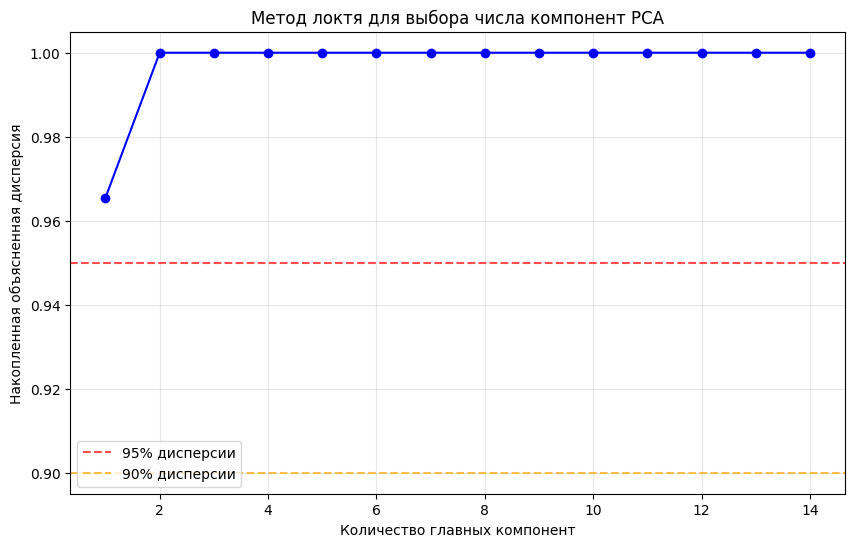

In [13]:
pca = PCA()
pca.fit(X_train_transformed)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% дисперсии')
plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Метод локтя для выбора числа компонент PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [14]:
pca_final = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pd.DataFrame(pca_final.fit_transform(X_train_transformed))

print(f"Размерность после PCA:")
print(f"Train: {X_train_pca.shape}")

Размерность после PCA:
Train: (8353, 2)


In [15]:
joblib.dump(pca_final, 'pca_model.pkl')

['pca_model.pkl']

In [16]:
X_train_pca.describe()

,0,1
count,8.353000e+03,8.353000e+03
mean,1.098900e-09,1.141715e-09
std,9.373923e+06,1.772484e+06
min,-1.068004e+07,-4.080219e+06
25%,-7.659879e+06,-1.872583e+06
50%,-3.144705e+06,6.791540e+05
75%,4.490547e+06,1.638749e+06
max,2.045758e+07,2.550406e+06


In [17]:
df_drop_original = X_train_drop.copy()

scaler_standard = StandardScaler()
df_drop_standardized = X_train_drop.copy()
df_drop_standardized = pd.DataFrame(scaler_standard.fit_transform(df_drop_standardized))

scaler_minmax = MinMaxScaler()
df_drop_minmax = X_train_drop.copy()
df_drop_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_drop_minmax))

scaler_robust = RobustScaler()
df_drop_robust = X_train_drop.copy()
df_drop_robust = pd.DataFrame(scaler_robust.fit_transform(df_drop_robust))

In [18]:
joblib.dump(scaler_standard, 'drop_scaler_standart.pkl')
joblib.dump(scaler_minmax, 'drop_scaler_minmax.pkl')
joblib.dump(scaler_robust, 'drop_scaler_robust.pkl')

['drop_scaler_robust.pkl']

In [19]:
df_original = X_train_pca.copy()

scaler_standard = StandardScaler()
df_standardized = X_train_pca.copy()
df_standardized = pd.DataFrame(scaler_standard.fit_transform(df_standardized))

scaler_minmax = MinMaxScaler()
df_minmax = X_train_pca.copy()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_minmax))

scaler_robust = RobustScaler()
df_robust = X_train_pca.copy()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df_robust))

In [20]:
joblib.dump(scaler_standard, 'pca_scaler_standart.pkl')
joblib.dump(scaler_minmax, 'pca_scaler_minmax.pkl')
joblib.dump(scaler_robust, 'pca_scaler_robust.pkl')

['pca_scaler_robust.pkl']

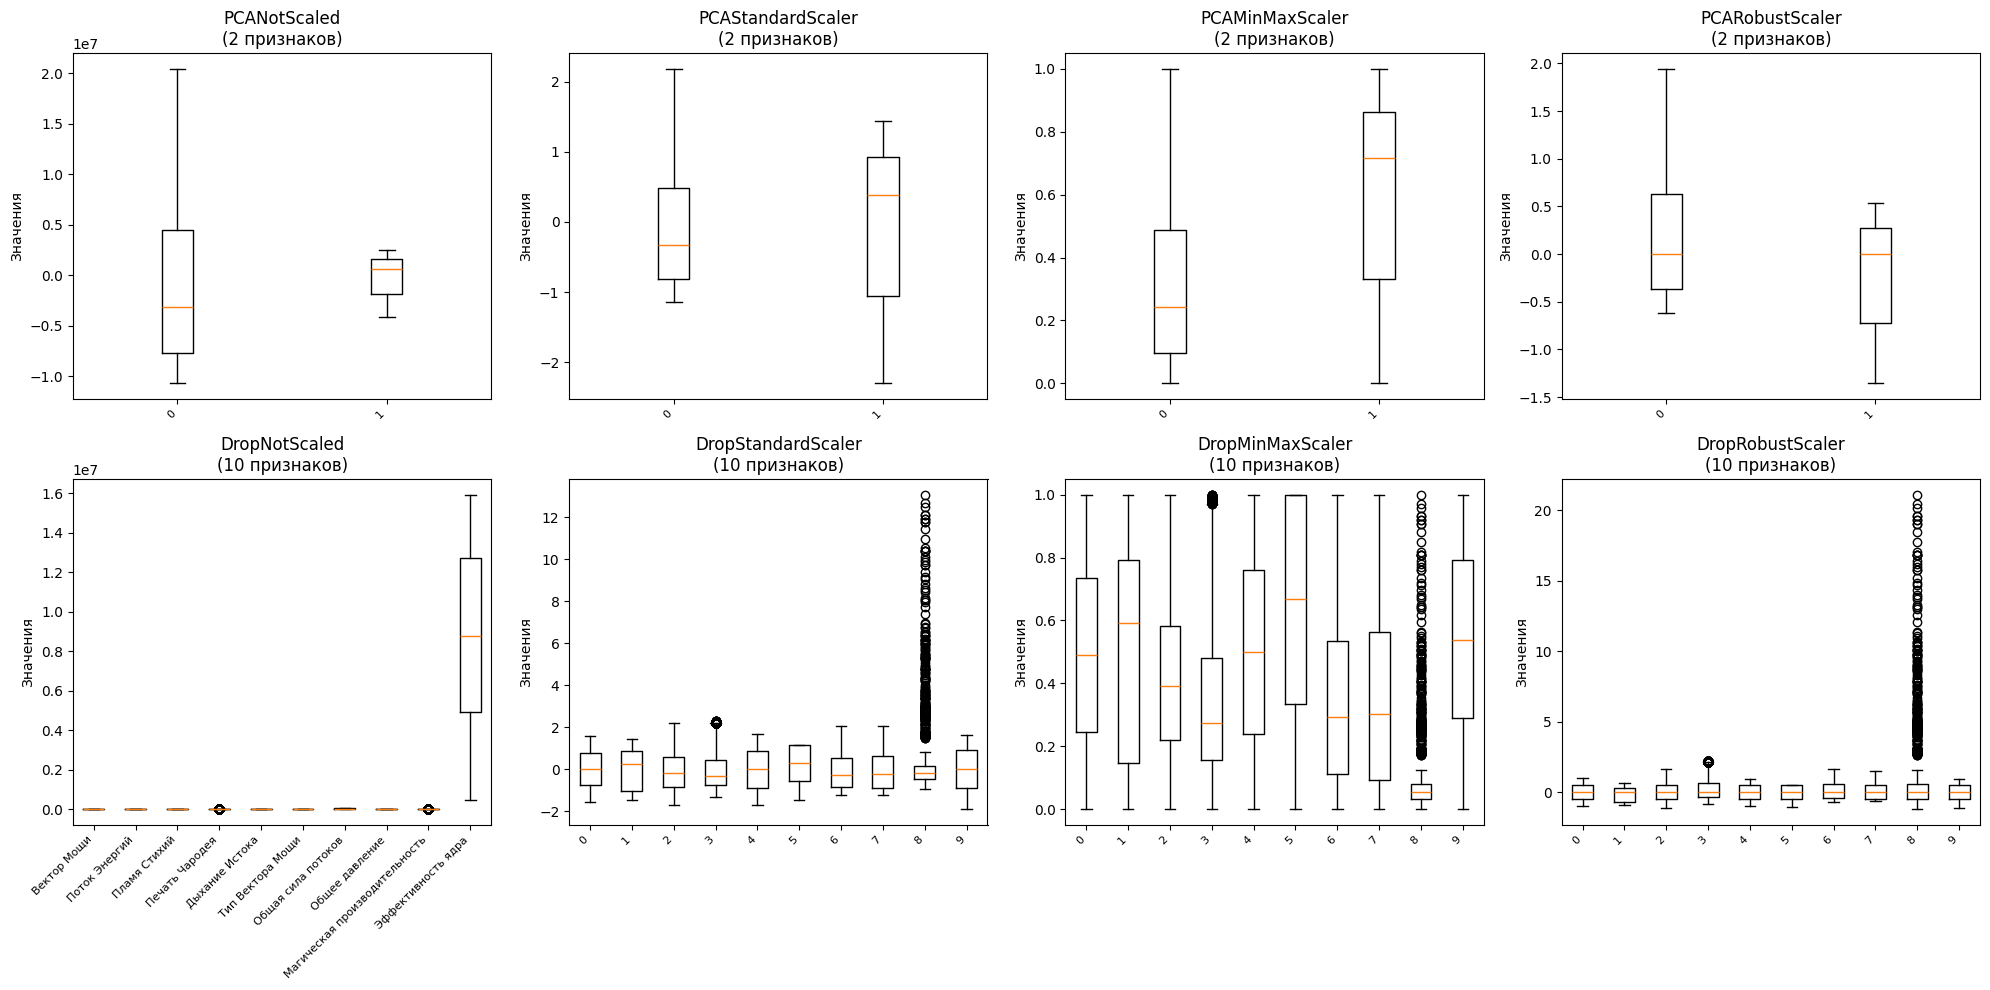

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

datasets = {
    'PCANotScaled': df_original,
    'PCAStandardScaler': df_standardized, 
    'PCAMinMaxScaler': df_minmax,
    'PCARobustScaler': df_robust,
    'DropNotScaled': X_train_drop,
    'DropStandardScaler': df_drop_standardized, 
    'DropMinMaxScaler': df_drop_minmax,
    'DropRobustScaler': df_drop_robust
}

for idx, (name, data) in enumerate(datasets.items()):
    axes[idx].boxplot(data.values)
    axes[idx].set_title(f'{name}\n({data.shape[1]} признаков)')
    axes[idx].set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Значения')

if len(datasets) < len(axes):
    axes[len(datasets)].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
for key, val in datasets.items():
    val.to_csv(f'X_train_{key.lower()}.csv', index=False)